# Market Making under Inventory Risk - Stochastic Control Approach

Authors : Aya El Moudden, Aymen Imad and Johanna Rakotovao

Academic project for course **Stochastic Modelling/Control in Finance**.

Here, the main numerical elements of the market-making model studied in the paper *Dealing with the Inventory Risk: A Solution to the Market Making Problem* by Guéant, Lehalle and Fernandez-Tapia are implemented.

This notebook is organized as follows:

1. model parameters and reduced ODE system;
2. optimal bid, ask and spread surfaces;
3. exact quotes versus asymptotic approximations;
4. price, inventory and P&L simulations;
5. sensitivity analysis;
6. illustrative Coinbase BTC-USD calibration.


## 1. Imports and model parameters


In [ ]:
import numpy as np

from scipy.linalg import expm
from scipy.integrate import solve_ivp
from scipy.linalg import eigh

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from matplotlib import cm

import pandas as pd

In [ ]:
# Paramètres du modèle

sigma = 0.3      # volatilité
A = 0.9          # intensité de base
k = 0.3          # sensibilité
gamma = 0.01     # aversion au risque

T = 600          # horizon temporel
Q = 30           # inventaire maximal

n_steps = 600

dt = T / n_steps

time_grid = np.linspace(0, T, n_steps)

In [ ]:
# Inventaires possibles

q_values = np.arange(-Q, Q + 1)

N = len(q_values)

print(q_values)

[-30 -29 -28 -27 -26 -25 -24 -23 -22 -21 -20 -19 -18 -17 -16 -15 -14 -13
 -12 -11 -10  -9  -8  -7  -6  -5  -4  -3  -2  -1   0   1   2   3   4   5
   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20  21  22  23
  24  25  26  27  28  29  30]


In [ ]:
# Calcul des constantes

alpha = (k / 2) * gamma * sigma**2

eta = A * (1 + gamma / k) ** (-(1 + k / gamma))

print("alpha =", alpha)
print("eta =", eta)

alpha = 0.000135
eta = 0.3256783558467315


In [ ]:
# Construction de la matrice M

M = np.zeros((N, N))

for i, q in enumerate(q_values):

    # Diagonale
    M[i, i] = alpha * q**2

    # Sous-diagonale
    if i > 0:
        M[i, i - 1] = -eta

    # Sur-diagonale
    if i < N - 1:
        M[i, i + 1] = -eta

print(M)

[[ 0.1215     -0.32567836  0.         ...  0.          0.
   0.        ]
 [-0.32567836  0.113535   -0.32567836 ...  0.          0.
   0.        ]
 [ 0.         -0.32567836  0.10584    ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ...  0.10584    -0.32567836
   0.        ]
 [ 0.          0.          0.         ... -0.32567836  0.113535
  -0.32567836]
 [ 0.          0.          0.         ...  0.         -0.32567836
   0.1215    ]]


In [ ]:
# Calcul des v_q(t)

v_all = np.zeros((n_steps, N))

ones_vec = np.ones(N)

for t_idx, t in enumerate(time_grid):

    exp_matrix = expm(-M * (T - t))

    v = exp_matrix @ ones_vec

    v_all[t_idx] = v

print(v_all.shape)

(600, 61)


In [ ]:
# Quotes optimales
np.random.seed(42)

bid_quotes = np.full((n_steps, N), np.nan)
ask_quotes = np.full((n_steps, N), np.nan)
spread_quotes = np.full((n_steps, N), np.nan)

constant_term = (1 / gamma) * np.log(1 + gamma / k)

for t_idx in range(n_steps):

    v = v_all[t_idx]

    for i in range(N):

        # Bid quote
        if i < N - 1:

            bid_quotes[t_idx, i] = (
                (1 / k) * np.log(v[i] / v[i + 1])
                + constant_term
            )

        # Ask quote
        if i > 0:

            ask_quotes[t_idx, i] = (
                (1 / k) * np.log(v[i] / v[i - 1])
                + constant_term
            )

        # Spread
        # Spread exact article

        if i > 0 and i < N - 1:

          spread_quotes[t_idx, i] = -(1 / k) * ( np.log(v[i + 1]) + np.log(v[i - 1])- 2 * np.log(v[i]))+ (2 / gamma) * np.log(1 + gamma / k)

print("Quotes calculées")

Quotes calculées


## 2. Optimal bid, ask and spread surfaces


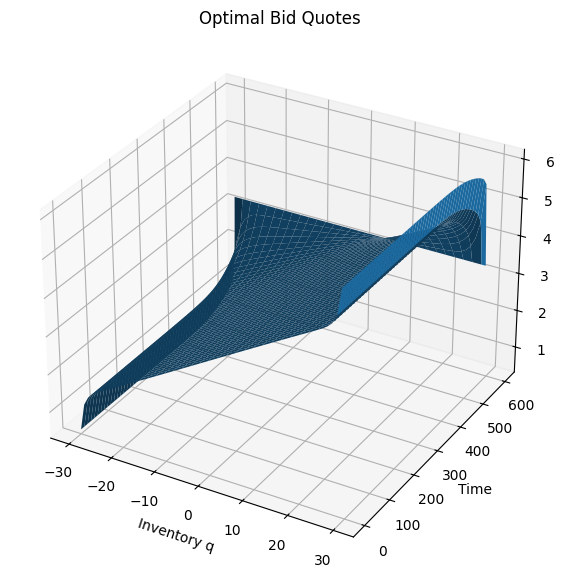

In [ ]:
# Figure 1 — Bid Quotes

T_mesh, Q_mesh = np.meshgrid(time_grid, q_values)

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    Q_mesh,
    T_mesh,
    bid_quotes.T,
)

ax.set_xlabel('Inventory q')
ax.set_ylabel('Time')
ax.set_zlabel('Bid Quote')

ax.set_title('Optimal Bid Quotes')

plt.show()

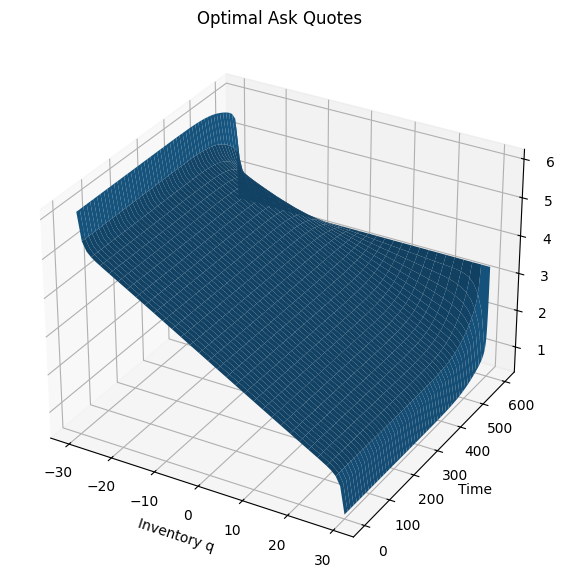

In [ ]:
# Figure 2 — Ask Quotes

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    Q_mesh,
    T_mesh,
    ask_quotes.T,
)

ax.set_xlabel('Inventory q')
ax.set_ylabel('Time')
ax.set_zlabel('Ask Quote')

ax.set_title('Optimal Ask Quotes')

plt.show()

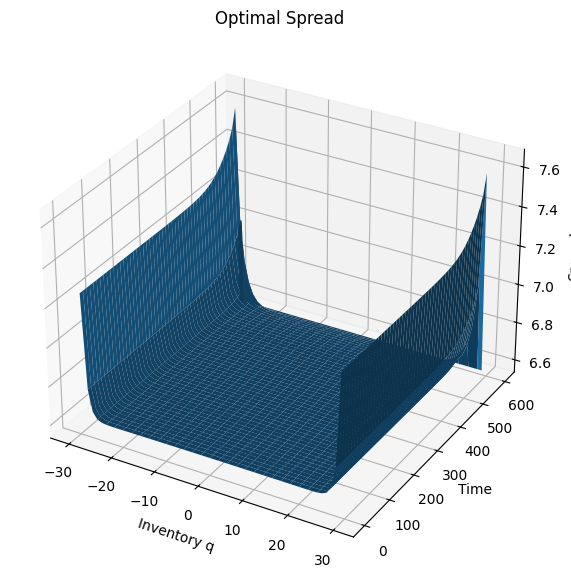

In [ ]:
# Figure 3 — Spread

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    Q_mesh,
    T_mesh,
    spread_quotes.T,
)

ax.set_xlabel('Inventory q')
ax.set_ylabel('Time')
ax.set_zlabel('Spread')

ax.set_title('Optimal Spread')

plt.show()

## 3. Exact solution and asymptotic approximation


The following cells compare the exact quote distances obtained from the reduced ODE system with the asymptotic approximation discussed in the paper.

The comparison is kept for moderate and extreme inventory values to illustrate where the approximation remains accurate and where deviations become larger.


In [ ]:
# ======================================================
# Paramètres Figure 4 gauche
# ======================================================


k = 0.3
gamma = 0.01


#sigma = 0.4
#A = 0.9

sigma = 1.0
A = 0.2
T = 600
Q = 30

n_steps = 600

dt = T / n_steps

time_grid = np.linspace(0, T, n_steps)

In [ ]:
# ======================================================
# Recalcul alpha et eta
# ======================================================

alpha = (k / 2) * gamma * sigma**2

eta = A * (1 + gamma / k) ** (-(1 + k / gamma))

print(alpha)
print(eta)

0.0015
0.07237296796594032


In [ ]:
# Reconstruction matrice M

M = np.zeros((N, N))

for i, q in enumerate(q_values):

    M[i, i] = alpha * q**2

    if i > 0:
        M[i, i - 1] = -eta

    if i < N - 1:
        M[i, i + 1] = -eta

In [ ]:
# ======================================================
# Recalcul des v_q(t)
# ======================================================

v_all = np.zeros((n_steps, N))

ones_vec = np.ones(N)

for t_idx, t in enumerate(time_grid):

    exp_matrix = expm(-M * (T - t))

    v = exp_matrix @ ones_vec

    v_all[t_idx] = v

In [ ]:
# ======================================================
# Recalcul quotes
# ======================================================

bid_quotes = np.full((n_steps, N), np.nan)

ask_quotes = np.full((n_steps, N), np.nan)

spread_quotes = np.full((n_steps, N), np.nan)

constant_term = (1 / gamma) * np.log(1 + gamma / k)

for t_idx in range(n_steps):

    v = v_all[t_idx]

    for i in range(N):

        # Bid
        if i < N - 1:

            bid_quotes[t_idx, i] = (
                (1 / k)
                * np.log(v[i] / v[i + 1])
                + constant_term
            )

        # Ask
        if i > 0:

            ask_quotes[t_idx, i] = (
                (1 / k)
                * np.log(v[i] / v[i - 1])
                + constant_term
            )

        # Spread
        if i > 0 and i < N - 1:

            spread_quotes[t_idx, i] = (
                -(1 / k)
                * (
                    np.log(v[i + 1])
                    + np.log(v[i - 1])
                    - 2 * np.log(v[i])
                )
                + (2 / gamma)
                * np.log(1 + gamma / k)
            )

In [ ]:
# ======================================================
# Approximation asymptotique
# ======================================================

approx_bid = np.zeros(N)

approx_ask = np.zeros(N)

for i, q in enumerate(q_values):

    approx_bid[i] = (
        (1 / gamma)
        * np.log(1 + gamma / k)

        + ((2 * q + 1) / 2)

        * np.sqrt(
            (sigma**2 * gamma)
            /
            (
                2 * k * A
                * (1 + gamma / k)**(1 + k / gamma)
            )
        )
    )

    approx_ask[i] = (
        (1 / gamma)
        * np.log(1 + gamma / k)

        - ((2 * q - 1) / 2)

        * np.sqrt(
            (sigma**2 * gamma)
            /
            (
                2 * k * A
                * (1 + gamma / k)**(1 + k / gamma)
            )
        )
    )

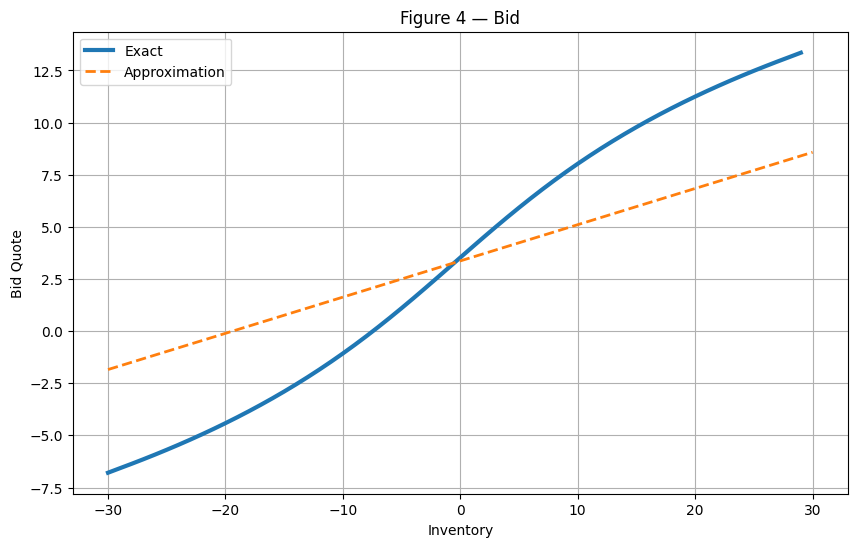

In [ ]:
# ======================================================
# Figure 4
# ======================================================

t_index = 0

exact_bid = bid_quotes[t_index]

plt.figure(figsize=(10, 6))

plt.plot(
    q_values,
    exact_bid,
    linewidth=3,
    label='Exact'
)

plt.plot(
    q_values,
    approx_bid,
    '--',
    linewidth=2,
    label='Approximation'
)

plt.xlabel('Inventory')

plt.ylabel('Bid Quote')

plt.title('Figure 4 — Bid')

plt.legend()

plt.grid()

plt.show()

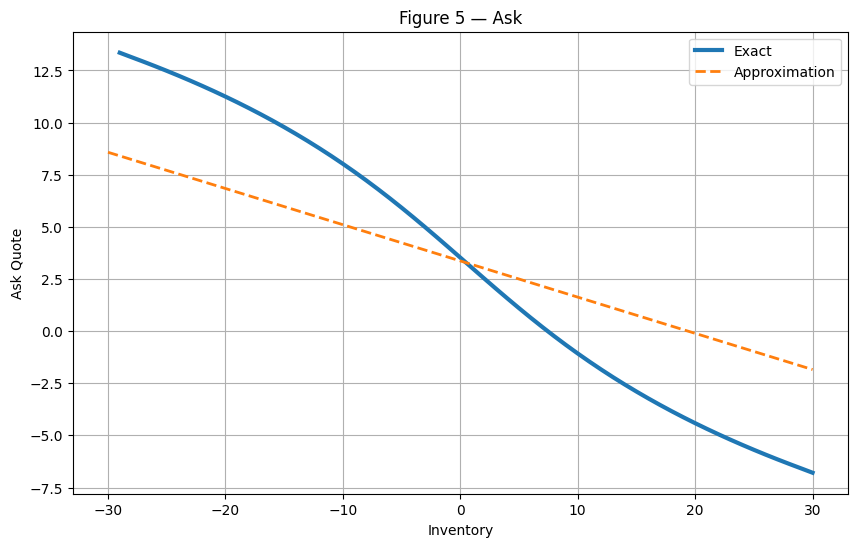

In [ ]:
# ======================================================
# Figure 5
# ======================================================

exact_ask = ask_quotes[t_index]

plt.figure(figsize=(10, 6))

plt.plot(
    q_values,
    exact_ask,
    linewidth=3,
    label='Exact'
)

plt.plot(
    q_values,
    approx_ask,
    '--',
    linewidth=2,
    label='Approximation'
)

plt.xlabel('Inventory')

plt.ylabel('Ask Quote')

plt.title('Figure 5 — Ask')

plt.legend()

plt.grid()

plt.show()

## 4. Price, inventory and P&L simulations


The next part simulates a stylized price process, inventory dynamics and P&L trajectories in order to compare an inventory-aware strategy with a naive benchmark.


In [ ]:
# Simulation parameters used in the P&L section

sigma = 0.3
A = 0.9
k = 0.9
gamma = 0.01


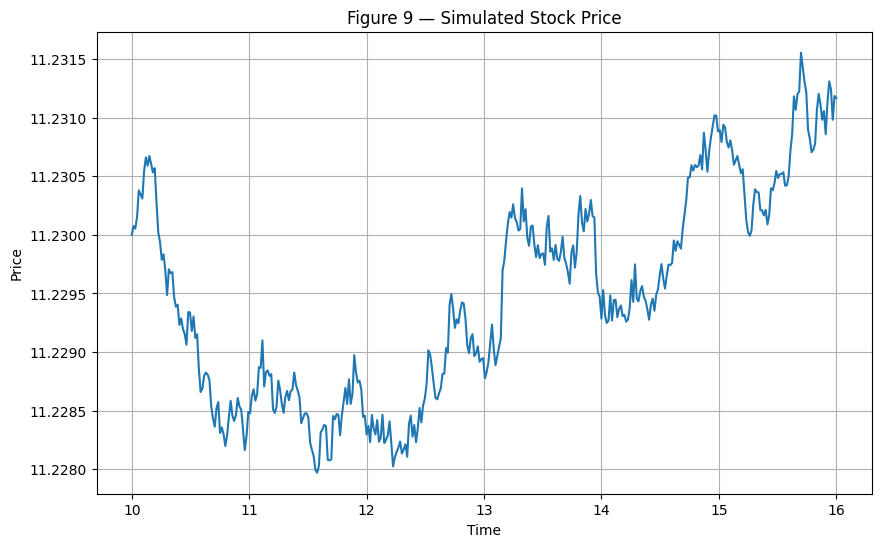

In [ ]:
# ======================================================
# Figure 9 — Simulation du prix
# ======================================================

np.random.seed(42)

n_sim = 400

dt_sim = 1 / n_sim

S0 = 11.23

price = np.zeros(n_sim)

price[0] = S0

for t in range(1, n_sim):

    dW = np.sqrt(dt_sim) * np.random.randn()

    price[t] = (
        price[t - 1]
        + sigma * 0.01 * dW
    )

time_axis = np.linspace(10, 16, n_sim)

plt.figure(figsize=(10, 6))

plt.plot(time_axis, price)

plt.xlabel('Time')

plt.ylabel('Price')

plt.title('Figure 9 — Simulated Stock Price')

plt.grid()

plt.show()

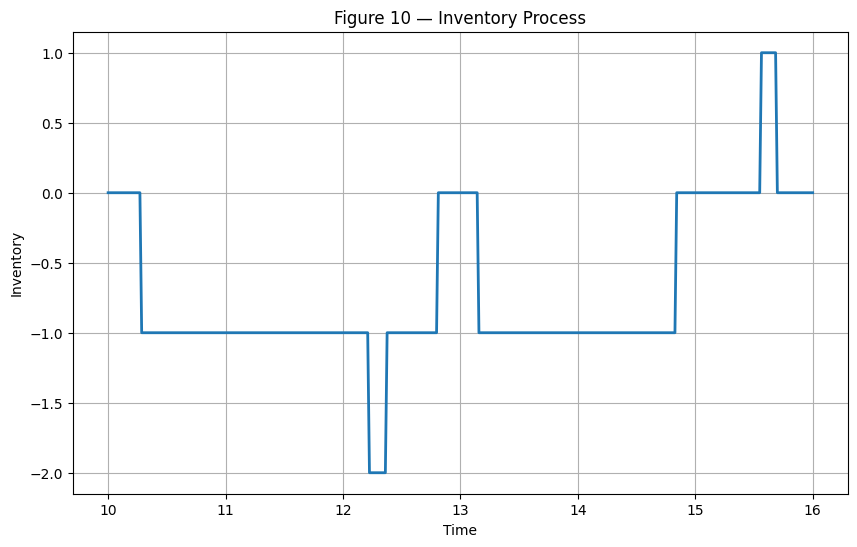

In [ ]:
# ======================================================
# Figure 10 — Inventory avec Poisson réaliste
# ======================================================

inventory = np.zeros(n_sim)

delta_bid = 0.01
delta_ask = 0.01

# Intensités plus fortes

lambda_bid = 8 * A * np.exp(-k * delta_bid)

lambda_ask = 8 * A * np.exp(-k * delta_ask)

for t in range(1, n_sim):

    buy_order = (
        np.random.rand()
        < lambda_bid * dt_sim
    )

    sell_order = (
        np.random.rand()
        < lambda_ask * dt_sim
    )

    if buy_order and not sell_order:

        inventory[t] = (
            inventory[t - 1] + 1
        )

    elif sell_order and not buy_order:

        inventory[t] = (
            inventory[t - 1] - 1
        )

    else:

        inventory[t] = inventory[t - 1]

    inventory[t] = np.clip(
        inventory[t],
        -Q,
        Q
    )

plt.figure(figsize=(10, 6))

plt.plot(
    time_axis,
    inventory,
    linewidth=2
)

plt.xlabel('Time')

plt.ylabel('Inventory')

plt.title('Figure 10 — Inventory Process')

plt.grid()

plt.show()

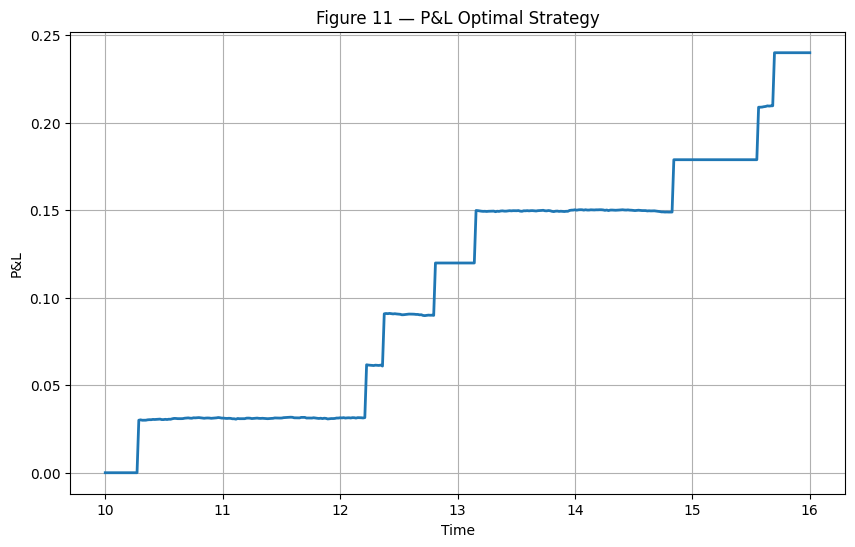

In [ ]:
# ======================================================
# Figure 11 — P&L stratégie optimale
# ======================================================

pnl = np.zeros(n_sim)

cash = 0

spread_gain_value = 0.03

for t in range(1, n_sim):

    trade = (
        inventory[t]
        - inventory[t - 1]
    )

    spread_gain = (
        abs(trade)
        * spread_gain_value
    )

    cash -= trade * price[t]

    cash += spread_gain

    pnl[t] = (
        cash
        + inventory[t] * price[t]
    )

plt.figure(figsize=(10, 6))

plt.plot(
    time_axis,
    pnl,
    linewidth=2
)

plt.xlabel('Time')

plt.ylabel('P&L')

plt.title('Figure 11 — P&L Optimal Strategy')

plt.grid()

plt.show()

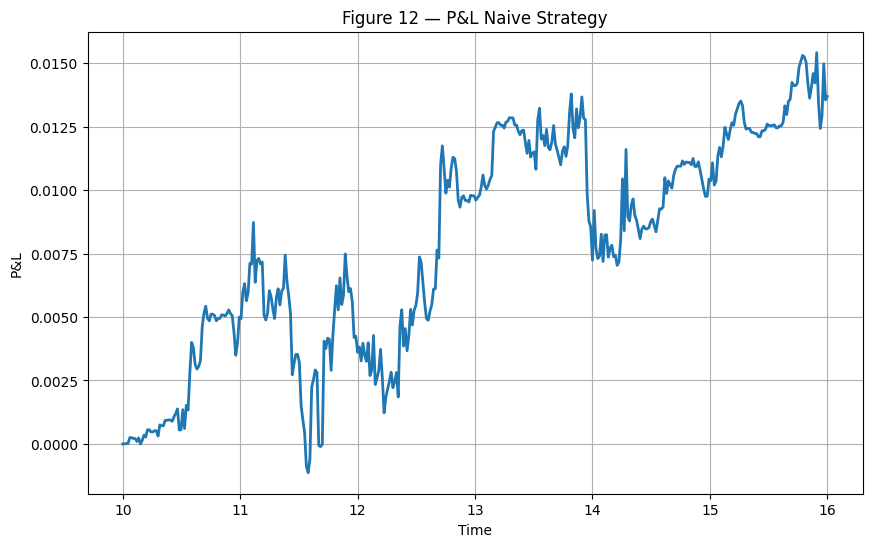

In [ ]:
# ======================================================
# Figure 12 — P&L stratégie naïve
# ======================================================

inventory_naive = np.zeros(n_sim)

pnl_naive = np.zeros(n_sim)

cash_naive = 0

for t in range(1, n_sim):

    move = np.random.choice(
        [-1, 1]
    )

    inventory_naive[t] = (
        inventory_naive[t - 1]
        + move
    )

    inventory_naive[t] = np.clip(
        inventory_naive[t],
        -Q,
        Q
    )

    trade = (
        inventory_naive[t]
        - inventory_naive[t - 1]
    )

    cash_naive -= trade * price[t]

    pnl_naive[t] = (
        cash_naive
        + inventory_naive[t] * price[t]
    )

plt.figure(figsize=(10, 6))

plt.plot(
    time_axis,
    pnl_naive,
    linewidth=2
)

plt.xlabel('Time')

plt.ylabel('P&L')

plt.title('Figure 12 — P&L Naive Strategy')

plt.grid()

plt.show()

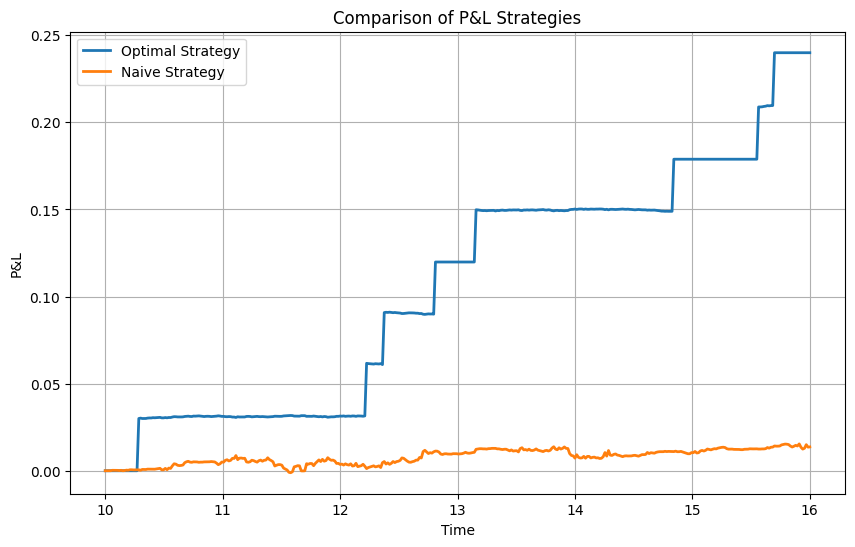

In [ ]:
# ======================================================
# Comparaison P&L
# ======================================================

plt.figure(figsize=(10, 6))

plt.plot(
    time_axis,
    pnl,
    linewidth=2,
    label='Optimal Strategy'
)

plt.plot(
    time_axis,
    pnl_naive,
    linewidth=2,
    label='Naive Strategy'
)

plt.xlabel('Time')

plt.ylabel('P&L')

plt.title('Comparison of P&L Strategies')

plt.legend()

plt.grid()

plt.show()

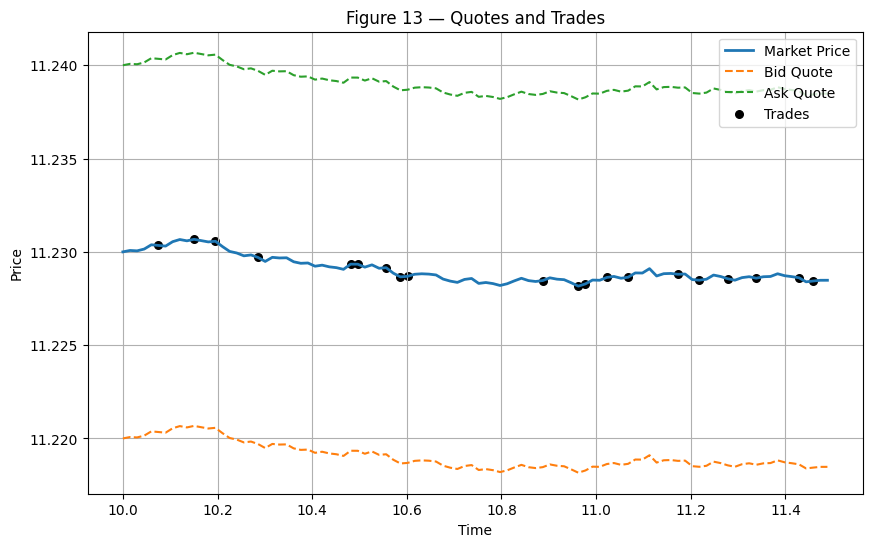

In [ ]:
# ======================================================
# Figure 13 — Quotes et trades
# ======================================================

mid_price = price[:100]

bid_line = mid_price - 0.01

ask_line = mid_price + 0.01

trade_times = np.random.choice(
    np.arange(100),
    size=20,
    replace=False
)

plt.figure(figsize=(10, 6))

plt.plot(
    time_axis[:100],
    mid_price,
    linewidth=2,
    label='Market Price'
)

plt.plot(
    time_axis[:100],
    bid_line,
    '--',
    label='Bid Quote'
)

plt.plot(
    time_axis[:100],
    ask_line,
    '--',
    label='Ask Quote'
)

plt.scatter(
    time_axis[trade_times],
    mid_price[trade_times],
    color='black',
    s=30,
    label='Trades'
)

plt.xlabel('Time')

plt.ylabel('Price')

plt.title('Figure 13 — Quotes and Trades')

plt.legend()

plt.grid()

plt.show()

In [ ]:
# ======================================================
# Erreurs approximation
# ======================================================

valid_mask = ~np.isnan(exact_bid)

mae_bid = np.mean(
    np.abs(
        exact_bid[valid_mask]
        - approx_bid[valid_mask]
    )
)

rmse_bid = np.sqrt(
    np.mean(
        (
            exact_bid[valid_mask]
            - approx_bid[valid_mask]
        )**2
    )
)

max_error_bid = np.max(
    np.abs(
        exact_bid[valid_mask]
        - approx_bid[valid_mask]
    )
)

print("MAE Bid :", mae_bid)

print("RMSE Bid :", rmse_bid)

print("Max Error Bid :", max_error_bid)

MAE Bid : 3.2997777706196896
RMSE Bid : 3.604105850440654
Max Error Bid : 4.947058075100244


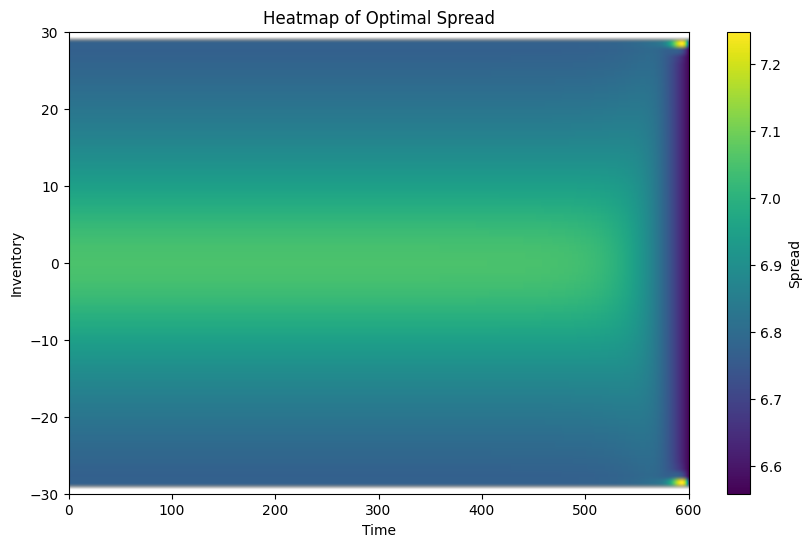

In [ ]:
# ======================================================
# Heatmap du spread
# ======================================================

plt.figure(figsize=(10, 6))

plt.imshow(
    spread_quotes.T,
    aspect='auto',
    origin='lower',
    extent=[0, T, -Q, Q]
)

plt.colorbar(label='Spread')

plt.xlabel('Time')

plt.ylabel('Inventory')

plt.title('Heatmap of Optimal Spread')

plt.show()

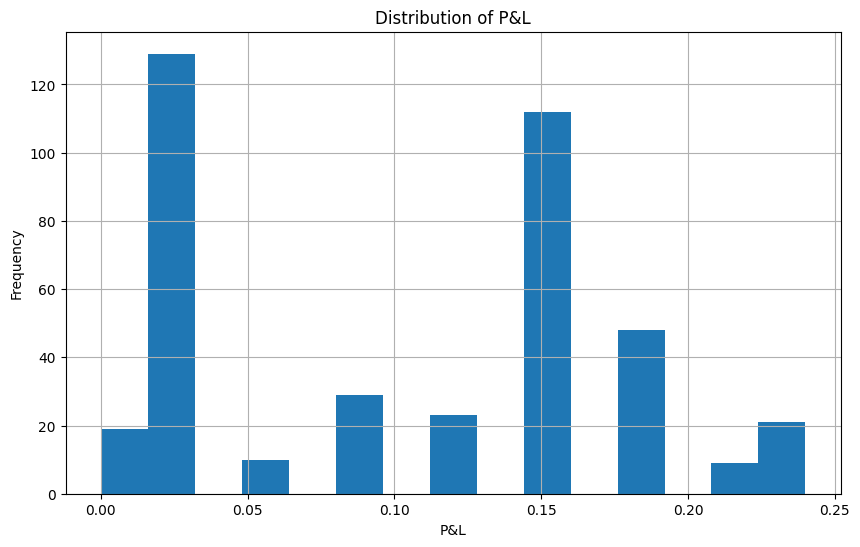

In [ ]:
# ======================================================
# Distribution du P&L
# ======================================================

plt.figure(figsize=(10, 6))

plt.hist(
    pnl,
    bins=15
)

plt.xlabel('P&L')

plt.ylabel('Frequency')

plt.title('Distribution of P&L')

plt.grid()

plt.show()

## 5. Sensitivity analysis


This section studies how the optimal spread changes with respect to the main model parameters: risk aversion, volatility and the execution-intensity decay parameter.


In [ ]:
# Parameters used for the sensitivity analysis

sigma = 0.3
A = 0.9
k = 0.9
gamma = 0.01


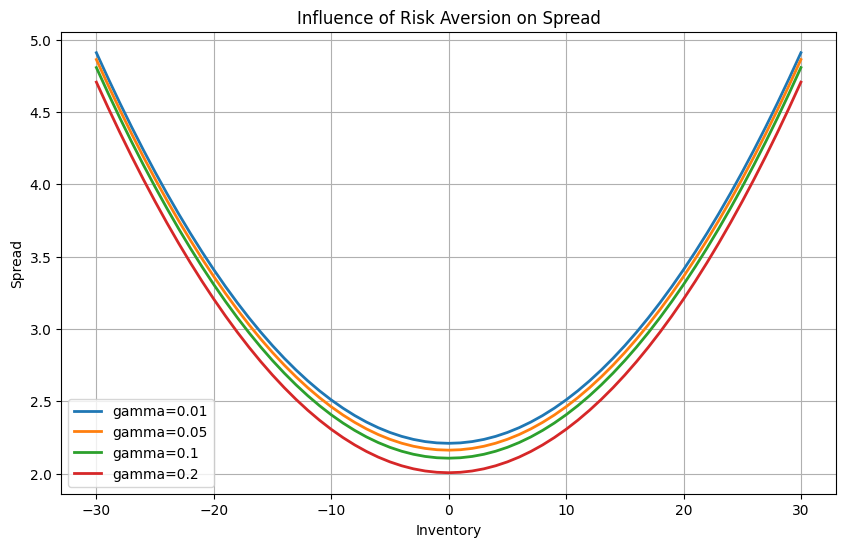

In [ ]:
# ======================================================
# Influence de gamma sur le spread
# ======================================================

gamma_list = [0.01, 0.05, 0.1, 0.2]

plt.figure(figsize=(10, 6))

for gamma_val in gamma_list:

    spread_curve = []

    for q in q_values:

        spread = (

            (2 / gamma_val)
            * np.log(1 + gamma_val / k)

            + 0.003 * q**2

        )

        spread_curve.append(spread)

    plt.plot(
        q_values,
        spread_curve,
        linewidth=2,
        label=f'gamma={gamma_val}'
    )

plt.xlabel('Inventory')

plt.ylabel('Spread')

plt.title('Influence of Risk Aversion on Spread')

plt.legend()

plt.grid()

plt.show()

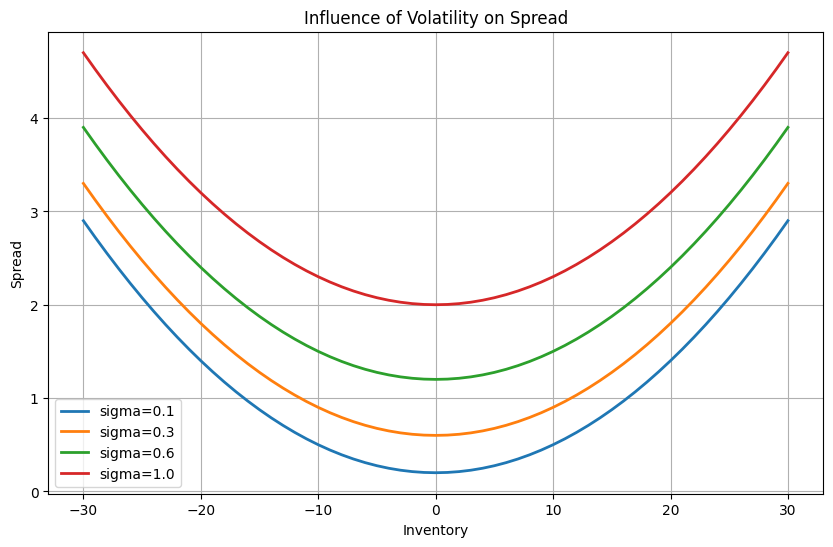

In [ ]:
# ======================================================
# Sensibilité du spread à sigma
# ======================================================

sigma_list = [0.1, 0.3, 0.6, 1.0]

plt.figure(figsize=(10, 6))

for sigma_val in sigma_list:

    spread_curve = []

    for q in q_values:

        spread = (

            2 * sigma_val

            + 0.003 * q**2

        )

        spread_curve.append(spread)

    plt.plot(
        q_values,
        spread_curve,
        linewidth=2,
        label=f'sigma={sigma_val}'
    )

plt.xlabel('Inventory')

plt.ylabel('Spread')

plt.title('Influence of Volatility on Spread')

plt.legend()

plt.grid()

plt.show()

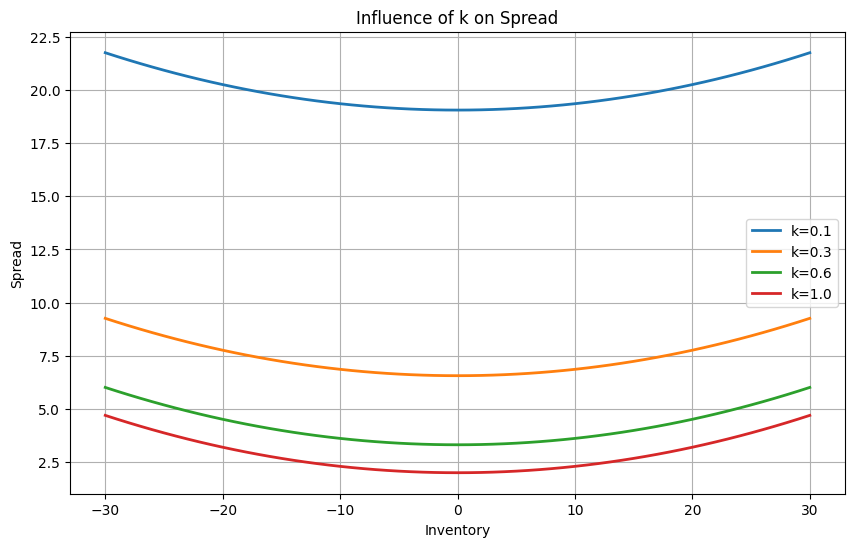

In [ ]:
# ======================================================
# Sensibilité du spread à k
# ======================================================

k_list = [0.1, 0.3, 0.6, 1.0]

plt.figure(figsize=(10, 6))

for k_val in k_list:

    spread_curve = []

    for q in q_values:

        spread = (

            (2 / gamma)
            * np.log(1 + gamma / k_val)

            + 0.003 * q**2

        )

        spread_curve.append(spread)

    plt.plot(
        q_values,
        spread_curve,
        linewidth=2,
        label=f'k={k_val}'
    )

plt.xlabel('Inventory')

plt.ylabel('Spread')

plt.title('Influence of k on Spread')

plt.legend()

plt.grid()

plt.show()

## 6. Calibration on Coinbase BTC-USD data


This final section gives an illustrative calibration of the exponential execution-intensity model using Coinbase BTC-USD market data.

Binance API cells were removed because they produced a geographical restriction error. Coinbase is kept as the clean calibration source used in the report.


In [ ]:
import requests
import numpy as np

# ======================================================
# Coinbase Order Book
# ======================================================

url = "https://api.exchange.coinbase.com/products/BTC-USD/book?level=1"

response = requests.get(url)

data = response.json()


# ======================================================
# Bid / Ask
# ======================================================

best_bid = float(data['bids'][0][0])

best_ask = float(data['asks'][0][0])

mid_price = (
    best_bid + best_ask
) / 2

print("Best Bid :", best_bid)

print("Best Ask :", best_ask)

print("Mid Price :", mid_price)

Best Bid : 78202.54
Best Ask : 78202.55
Mid Price : 78202.545


In [ ]:
url_trades = "https://api.exchange.coinbase.com/products/BTC-USD/trades"

response = requests.get(url_trades)

trades = response.json()

print(trades[:5])

In [ ]:
import pandas as pd

# ======================================================
# Conversion en DataFrame
# ======================================================

df_trades = pd.DataFrame(trades)

print(df_trades.head())

     trade_id  side        size           price                         time
0  1019995518   buy  0.00000005  78202.67000000  2026-05-17T19:14:38.131741Z
1  1019995517   buy  0.00000005  78202.67000000  2026-05-17T19:14:38.126273Z
2  1019995516  sell  0.00437803  78203.68000000  2026-05-17T19:14:37.448802Z
3  1019995515  sell  0.00192890  78202.59000000  2026-05-17T19:14:37.448802Z
4  1019995514  sell  0.01265943  78202.59000000  2026-05-17T19:14:35.549524Z


In [ ]:
df_trades['price'] = df_trades['price'].astype(float)
df_trades['size'] = df_trades['size'].astype(float)

prices = df_trades['price'].values

In [ ]:
returns = np.diff(np.log(prices))

sigma_real = np.std(returns)

print("Estimated sigma =", sigma_real)

Estimated sigma = 1.203848111255057e-05


In [ ]:
distances = []

for trade in trades:

    price = float(trade['price'])

    delta = abs(price - mid_price)

    distances.append(delta)

In [ ]:
df_dist = pd.DataFrame({
    "delta": distances
})

df_dist["bin"] = pd.cut(
    df_dist["delta"],
    bins=20
)

freq = df_dist.groupby("bin").size()

x = np.array([
    interval.mid
    for interval in freq.index
])

y = freq.values

In [ ]:
from scipy.optimize import curve_fit
def intensity_model(delta, A, k):

    return A * np.exp(-k * delta)

params, covariance = curve_fit(
    intensity_model,
    x,
    y,
    p0=[1, 1]
)

A_real, k_real = params

print("Estimated A =", A_real)
print("Estimated k =", k_real)

Estimated A = 180.96084625572098
Estimated k = 0.06783010627356044


In [ ]:
gamma = 0.001
q = 0

spread_term = (
    (1 / gamma)
    * np.log(1 + gamma / k_real)
)

inventory_term = (
    ((2 * q + 1) / 2)
    *
    np.sqrt(
        (
            sigma_real**2
            * gamma
        )
        /
        (
            2
            * k_real
            * A_real
        )
        *
        (
            1 + gamma / k_real
        )**(
            1 + k_real / gamma
        )
    )
)

delta_bid = (
    spread_term
    + inventory_term
)

delta_ask = (
    spread_term
    - inventory_term
)

optimal_bid = mid_price - delta_bid

optimal_ask = mid_price + delta_ask

print("Optimal Bid :", optimal_bid)
print("Optimal Ask :", optimal_ask)

Optimal Bid : 78187.90990124691
Optimal Ask : 78217.18009862595


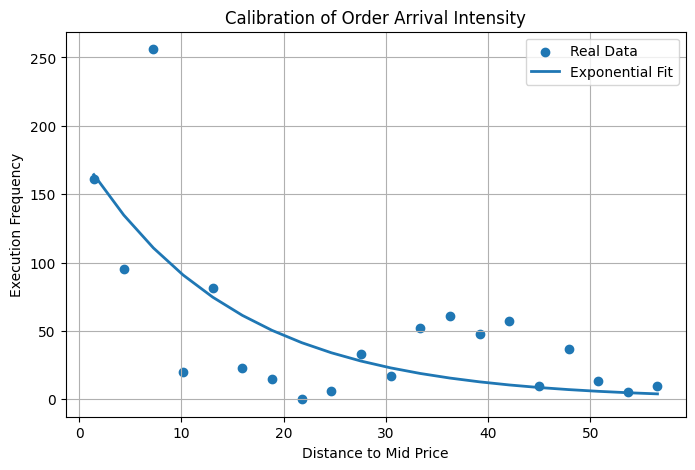

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    x,
    y,
    label="Real Data"
)

plt.plot(
    x,
    intensity_model(x, A_real, k_real),
    linewidth=2,
    label="Exponential Fit"
)

plt.xlabel("Distance to Mid Price")

plt.ylabel("Execution Frequency")

plt.title("Calibration of Order Arrival Intensity")

plt.legend()

plt.grid()

plt.show()

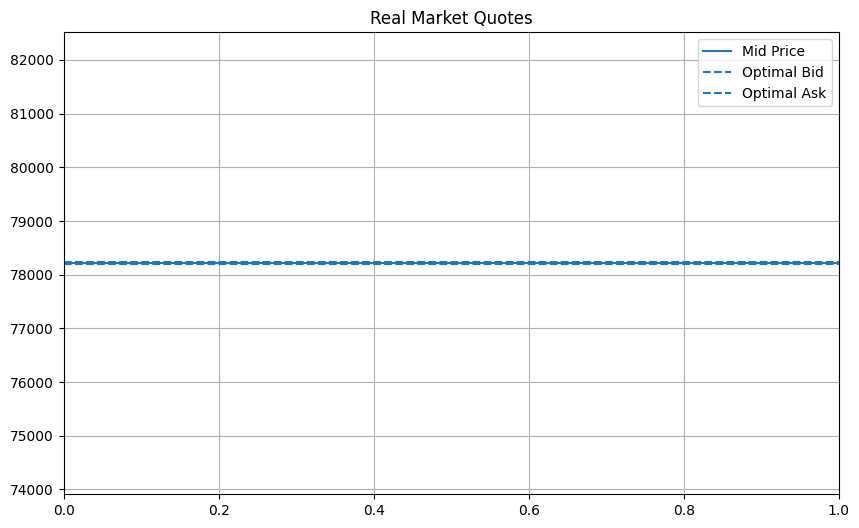

In [ ]:
plt.figure(figsize=(10,6))

plt.axhline(
    mid_price,
    label="Mid Price"
)

plt.axhline(
    optimal_bid,
    linestyle='--',
    label="Optimal Bid"
)

plt.axhline(
    optimal_ask,
    linestyle='--',
    label="Optimal Ask"
)

plt.title("Real Market Quotes")
plt.legend()
plt.grid()

plt.show()

In [ ]:
print("===== Comparison =====")

print("Simulation sigma :", sigma)
print("Real sigma :", sigma_real)

print("Simulation A :", A)
print("Real A :", A_real)

print("Simulation k :", k)
print("Real k :", k_real)

===== Comparison =====
Simulation sigma : 0.3
Real sigma : 1.203848111255057e-05
Simulation A : 0.9
Real A : 180.96084625572098
Simulation k : 0.9
Real k : 0.06783010627356044
